# Notebook 2 — Transfer Learning with ResNet18 + CLIP Zero-Shot Classification

**IOAI 2026 syllabus topics covered here:**
- *Pre-trained Vision Encoders (e.g. ResNet)* (Practice)
- *Model Finetuning* (Practice) — freeze-backbone (linear probe) **vs** full finetune
- *Vision-text encoders (e.g. CLIP)* (Practice)
- Supporting theory: *image embeddings*, *Transformers / attention / patching* (needed to understand CLIP's ViT image encoder)

**The big idea of this notebook:** in Notebook 1 we trained a CNN *from scratch* on a few thousand images and got modest accuracy. Almost nobody does that in practice (or at an olympiad). Instead you start from a network **pretrained on millions of images** and adapt it. We'll see *why* that works, *two ways* to do it, and then meet **CLIP** — a model that can classify images it was never explicitly trained to classify, using nothing but text prompts.

> ⏱️ CPU-friendly: small data subsets, few epochs, small input resolution. First run downloads pretrained weights (~45 MB for ResNet18, ~600 MB for CLIP).

## 1. Why transfer learning works

A CNN trained on ImageNet (1.28M photos, 1000 classes) has already learned a *general-purpose visual vocabulary*: edges → textures → parts → objects. The early and middle layers are not "ImageNet-specific" — edge and texture detectors are useful for **any** photo task. So instead of relearning vision from scratch on our small dataset, we:

1. take the pretrained network,
2. chop off its final 1000-class layer,
3. attach a fresh layer for *our* classes,
4. train — either a little or a lot.

The pretrained body acts as a **vision encoder**: image in → feature **embedding** out (for ResNet18, a 512-dim vector). Our new layer just learns to separate our classes inside that embedding space.

**ResNet** in one paragraph (you should know what you're loading): very deep plain CNNs used to *degrade* with depth because gradients struggle to flow through many layers. ResNet's fix is the **residual (skip) connection**: each block computes `F(x)` and outputs `x + F(x)`. The block only needs to learn the *change* (residual) to its input, and the identity path gives gradients a highway straight back to early layers. That single trick made 18-, 50-, even 152-layer networks trainable, and ResNets became the default pretrained encoder.

## 2. Setup

In [1]:
import random, time, copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")
t_start = time.time()

PyTorch 2.12.0+cpu | device: cpu


## 3. Data — CIFAR-10 subset, resized for a pretrained model

One crucial, easily-forgotten rule of transfer learning: **preprocess your images the way the pretrained model expects.** ResNet18 was trained on ImageNet images normalised with ImageNet's channel means/stds — so we use *those* statistics, **not** CIFAR's. Feed it differently-scaled inputs and the pretrained features silently degrade.

ImageNet models normally take 224×224 inputs. To keep this notebook fast on CPU we resize CIFAR's 32×32 images to **96×96** — a compromise: big enough for pretrained filters to be useful, small enough to be quick. (Convolutions don't care about exact input size; only the final pooling/head must adapt, and ResNet uses global average pooling, which handles any size.)

We use a deliberately **tiny training set (1,000 images)** — exactly the regime where transfer learning shines and training from scratch struggles.

In [2]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)   # use the PRETRAINED model's stats!
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize(96),
    T.RandomHorizontalFlip(),           # light augmentation still helps
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_tf = T.Compose([
    T.Resize(96),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

DATA_DIR = "./data"
USING_FAKE_DATA = False
try:
    train_full = torchvision.datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=train_tf)
    test_full  = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_tf)
    classes = train_full.classes
except Exception as e:
    # ── FALLBACK (clearly marked) ────────────────────────────────────────────
    # No internet / download failure -> FakeData random-noise images so the
    # notebook still executes. Accuracies will be ~10% (chance) — expected.
    print(f"CIFAR-10 download failed ({e!r}) -> falling back to FakeData.")
    USING_FAKE_DATA = True
    train_full = torchvision.datasets.FakeData(2000, (3, 96, 96), 10, transform=T.Compose([T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]))
    test_full  = torchvision.datasets.FakeData(500,  (3, 96, 96), 10, transform=T.Compose([T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]))
    classes = [f"class_{i}" for i in range(10)]

N_TRAIN, N_TEST = 1000, 500
g = torch.Generator().manual_seed(SEED)
train_set = Subset(train_full, torch.randperm(len(train_full), generator=g)[:N_TRAIN].tolist())
test_set  = Subset(test_full,  torch.randperm(len(test_full),  generator=g)[:N_TEST].tolist())
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=0)
print(f"train: {len(train_set)} | test: {len(test_set)} | input after resize: {train_set[0][0].shape}")

  entry = pickle.load(f, encoding="latin1")


train: 1000 | test: 500 | input after resize: torch.Size([3, 96, 96])


## 4. Load pretrained ResNet18 and swap the head

`torchvision.models.resnet18(weights=...)` downloads weights pretrained on ImageNet. The final layer `model.fc` is `Linear(512, 1000)` — 1000 ImageNet classes. We replace it with `Linear(512, 10)` for CIFAR-10. Everything *before* `fc` is the **encoder** producing the 512-dim embedding.

If the weight download fails we fall back (clearly marked) to randomly-initialised ResNet18 — the code path is identical, but the "pretrained advantage" disappears, which itself is instructive.

In [3]:
from torchvision.models import resnet18, ResNet18_Weights

PRETRAINED = True
try:
    base_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
except Exception as e:
    # ── FALLBACK (clearly marked): random init if weight download fails ─────
    print(f"Pretrained weight download failed ({e!r}) -> using RANDOM weights.")
    PRETRAINED = False
    base_model = resnet18(weights=None)

print("original head:", base_model.fc)
n_feat = base_model.fc.in_features      # 512 for ResNet18
print(f"encoder embedding size: {n_feat}")

original head: Linear(in_features=512, out_features=1000, bias=True)
encoder embedding size: 512


## 5. Two finetuning strategies — freeze vs full

| | **Frozen backbone** (linear probe) | **Full finetune** |
|---|---|---|
| What trains | only the new `fc` layer (~5K params) | all ~11M params |
| Speed / memory | fast — no gradients through the body | slow — backprop through everything |
| Data needed | works with *very* little data | needs more data or it overfits |
| Risk | features can't adapt to your domain | can *destroy* good pretrained features if LR too high ("catastrophic forgetting") |
| When to choose | tiny dataset, tight compute, domain similar to pretraining | enough data/compute, or domain quite different (e.g. medical scans) |

Practical rules worth memorising:
- **Freezing** = `param.requires_grad = False` → autograd skips those parameters entirely; the optimizer should only receive the trainable ones.
- For **full finetuning use a small learning rate** (we use 10× smaller). The pretrained weights are already good; big steps wreck them.
- Middle grounds exist (unfreeze only the last block, or use per-layer learning rates), but freeze-vs-full is the core trade-off.

We train both for the same 2 epochs on the same 1,000 images and compare.

In [4]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 2

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

def train_model(model, optimizer, epochs, tag):
    accs = []
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
        acc = evaluate(model, test_loader)
        accs.append(acc)
        print(f"[{tag}] epoch {epoch}/{epochs} | test acc {acc:.3f} | elapsed {time.time()-t_start:.0f}s")
    return accs

# ── Strategy A: FROZEN backbone (linear probe) ──────────────────────────────
torch.manual_seed(SEED)
model_frozen = copy.deepcopy(base_model)
for p in model_frozen.parameters():
    p.requires_grad = False                  # freeze EVERYTHING ...
model_frozen.fc = nn.Linear(n_feat, 10)      # ... new head is trainable by default
model_frozen = model_frozen.to(device)
opt_frozen = torch.optim.Adam(model_frozen.fc.parameters(), lr=1e-3)  # only head params!
n_trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
print(f"frozen-backbone model: {n_trainable:,} trainable params")
acc_frozen = train_model(model_frozen, opt_frozen, EPOCHS, "frozen")

frozen-backbone model: 5,130 trainable params


[frozen] epoch 1/2 | test acc 0.414 | elapsed 18s


[frozen] epoch 2/2 | test acc 0.564 | elapsed 35s


In [5]:
# ── Strategy B: FULL finetune ────────────────────────────────────────────────
torch.manual_seed(SEED)
model_full = copy.deepcopy(base_model)
model_full.fc = nn.Linear(n_feat, 10)
model_full = model_full.to(device)
opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-4)  # 10x SMALLER lr: protect pretrained weights
n_trainable = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
print(f"full-finetune model: {n_trainable:,} trainable params")
acc_full = train_model(model_full, opt_full, EPOCHS, "full")

full-finetune model: 11,181,642 trainable params


[full] epoch 1/2 | test acc 0.588 | elapsed 69s


[full] epoch 2/2 | test acc 0.742 | elapsed 103s


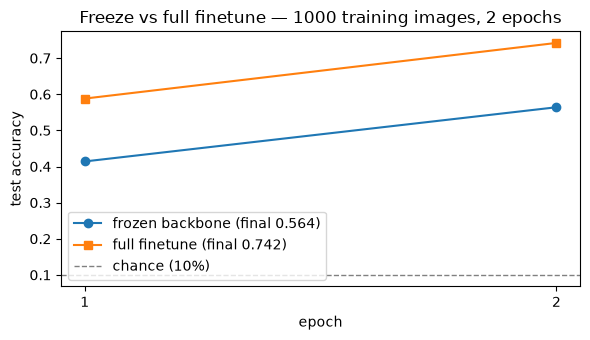

Notebook-1's from-scratch CNN needed 4,000 images + 3 epochs for a similar/lower score.


In [6]:
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, EPOCHS+1), acc_frozen, marker="o", label=f"frozen backbone (final {acc_frozen[-1]:.3f})")
plt.plot(range(1, EPOCHS+1), acc_full,   marker="s", label=f"full finetune (final {acc_full[-1]:.3f})")
plt.axhline(0.10, color="gray", ls="--", lw=1, label="chance (10%)")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.xticks(range(1, EPOCHS+1))
plt.title(f"Freeze vs full finetune — {N_TRAIN} training images, {EPOCHS} epochs")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Notebook-1's from-scratch CNN needed 4,000 images + 3 epochs for a similar/lower score.")

### Reading the result

With only **1,000 images and 2 epochs**, both transfer strategies typically already match or beat the from-scratch CNN of Notebook 1 (which used 4× more data) — that's the pretrained vocabulary paying off. Full finetuning usually edges ahead because the features can adapt, but it costs ~5–10× more compute per epoch here; with even less data or fewer steps, the frozen probe can win. **Competition heuristic:** start with a frozen linear probe (cheap, strong baseline, hard to break), then unfreeze if you have data and time left.

*(If the pretrained-weights download failed and this notebook fell back to random weights, both curves will sit much lower — the gap between them and Notebook 1 is precisely the value of pretraining.)*

## 6. CLIP — a vision-*text* encoder and zero-shot classification

Everything so far required labelled training images. **CLIP** (Contrastive Language–Image Pretraining) removes even that.

**How it was trained:** on ~400M (image, caption) pairs from the web, with **two encoders**:
- an **image encoder** — a **Vision Transformer (ViT)**: the image is cut into 32×32 **patches**, each patch is linearly projected to a vector (a patch embedding, plus a position embedding), and a **Transformer** processes the patch sequence with **self-attention** — every patch can directly exchange information with every other patch, so global relationships are captured in one layer rather than through many stacked convolutions;
- a **text encoder** — a Transformer over caption tokens.

Both encoders map into the **same embedding space**, trained **contrastively**: for a batch of N pairs, make each image embedding most similar (highest cosine similarity) to *its own* caption's embedding and dissimilar to the other N−1 captions.

**Why that enables zero-shot classification:** a classifier is just "which description matches this image best?". So:
1. Write one text **prompt per class**: `"a photo of a cat"`, `"a photo of a truck"`, …
2. Embed all prompts with the text encoder, embed the image with the image encoder.
3. Cosine similarity image↔each prompt → softmax → class probabilities.

No training images, no finetuning — the "classifier weights" are literally written in English. Prompt wording matters ("a photo of a {class}" beats the bare class name because it resembles the captions CLIP saw during pretraining).

In [7]:
CLIP_OK = True
try:
    from transformers import CLIPModel, CLIPProcessor
    clip_name = "openai/clip-vit-base-patch32"   # ViT image encoder with 32x32 patches
    clip_model = CLIPModel.from_pretrained(clip_name).to(device).eval()
    clip_proc = CLIPProcessor.from_pretrained(clip_name)
    print(f"loaded {clip_name} | elapsed {time.time()-t_start:.0f}s")
except Exception as e:
    # ── FALLBACK (clearly marked): skip the CLIP demo if download fails ─────
    CLIP_OK = False
    print(f"CLIP download failed ({e!r}) -> skipping the zero-shot demo cells below.")

  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 12685.87it/s]

loaded openai/clip-vit-base-patch32 | elapsed 110s


### Zero-shot CIFAR-10

We hand CLIP raw CIFAR-10 test images (as PIL images — the `CLIPProcessor` does CLIP's own resizing/normalisation; never reuse another model's preprocessing!) and the ten prompts. CLIP has **never been trained on CIFAR-10**, yet watch the accuracy.

One `clip_model(**inputs)` call runs both encoders and returns `logits_per_image`, where entry `[i, j]` = `logit_scale · cosine_sim(image_i, prompt_j)`. The `logit_scale` is a learned **temperature** that sharpens the softmax (CLIP learned its value during training). In the first batch we also recompute these logits *by hand* from the returned image/text embeddings — L2-normalise, dot product, scale — to prove there is no magic inside.

In [8]:
if CLIP_OK and not USING_FAKE_DATA:
    # raw PIL test images (bypass our tensor transforms on purpose)
    raw_test = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=False)
    idxs = torch.randperm(len(raw_test), generator=torch.Generator().manual_seed(SEED))[:200].tolist()

    prompts = [f"a photo of a {c}" for c in classes]
    with torch.no_grad():
        correct = 0
        sample_results = []
        for start in range(0, len(idxs), 50):                      # batches of 50
            batch_idx = idxs[start:start+50]
            pil_imgs = [raw_test[i][0] for i in batch_idx]
            labels = torch.tensor([raw_test[i][1] for i in batch_idx])
            inputs = clip_proc(text=prompts, images=pil_imgs, return_tensors="pt", padding=True).to(device)
            out = clip_model(**inputs)                  # runs BOTH encoders
            # logits_per_image[i, j] = logit_scale * cos_sim(image_i, prompt_j)
            probs = out.logits_per_image.softmax(dim=-1).cpu()
            correct += (probs.argmax(1) == labels).sum().item()
            if start == 0:
                # no magic: recompute the logits by hand from the embeddings
                img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
                txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
                manual = clip_model.logit_scale.exp() * img_emb @ txt_emb.T
                print("hand-computed cosine logits match logits_per_image:",
                      torch.allclose(manual, out.logits_per_image, atol=1e-3))
                sample_results = [(pil_imgs[i], labels[i].item(), probs[i]) for i in range(6)]
    print(f"CLIP zero-shot accuracy on 200 CIFAR-10 images: {correct/len(idxs):.3f}")
    print("(no CIFAR-10 training images were used — only English prompts!)")
elif CLIP_OK and USING_FAKE_DATA:
    print("FakeData fallback active -> zero-shot accuracy on noise is meaningless; skipping.")
else:
    print("CLIP unavailable -> skipped.")

  entry = pickle.load(f, encoding="latin1")


hand-computed cosine logits match logits_per_image: True


CLIP zero-shot accuracy on 200 CIFAR-10 images: 0.885
(no CIFAR-10 training images were used — only English prompts!)


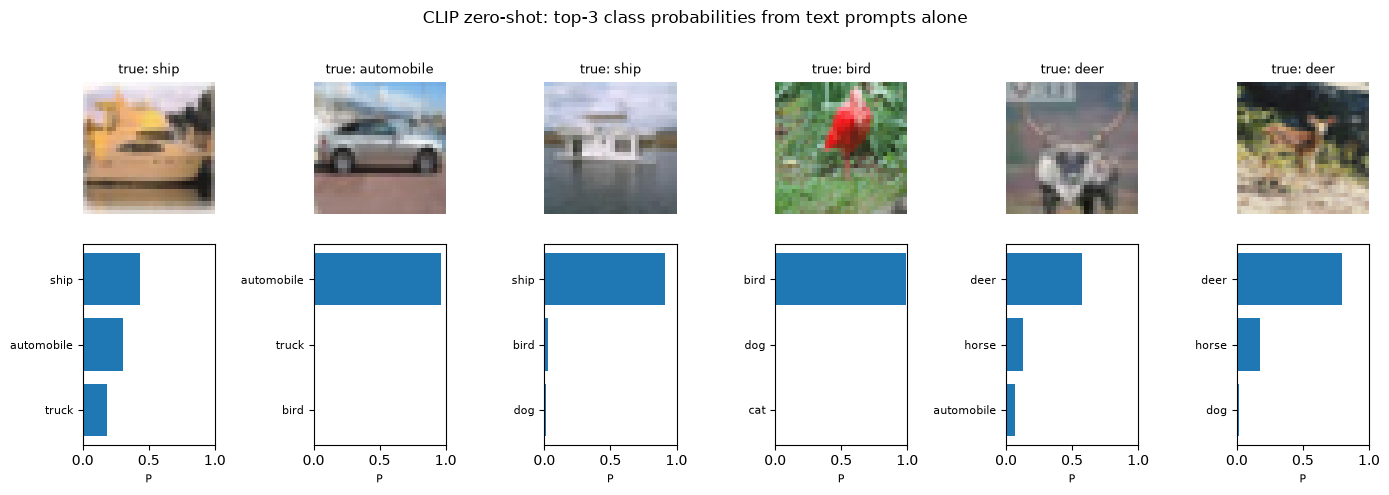

Total notebook runtime: 128s


In [9]:
if CLIP_OK and not USING_FAKE_DATA:
    fig, axes = plt.subplots(2, 6, figsize=(14, 5), gridspec_kw={"height_ratios": [1, 1.2]})
    for col, (img, lbl, probs) in enumerate(sample_results):
        axes[0, col].imshow(img); axes[0, col].axis("off")
        axes[0, col].set_title(f"true: {classes[lbl]}", fontsize=9)
        top = probs.topk(3)
        names = [classes[i] for i in top.indices]
        axes[1, col].barh(range(3)[::-1], top.values.numpy())
        axes[1, col].set_yticks(range(3)[::-1]); axes[1, col].set_yticklabels(names, fontsize=8)
        axes[1, col].set_xlim(0, 1); axes[1, col].set_xlabel("P", fontsize=8)
    plt.suptitle("CLIP zero-shot: top-3 class probabilities from text prompts alone")
    plt.tight_layout(); plt.show()
else:
    print("CLIP demo skipped (see fallback note above).")
print(f"Total notebook runtime: {time.time() - t_start:.0f}s")

## 7. Recap

- **Pretrained encoders** (ResNet18 here) give you a strong, general visual embedding — the single biggest practical lever in applied vision.
- **Residual connections** (`x + F(x)`) are what make very deep CNNs trainable.
- **Frozen backbone** = train only the new head: cheap, data-efficient, robust. **Full finetune** = adapt everything: stronger ceiling, needs a *small* learning rate and more data/compute. Try frozen first.
- Always match the **preprocessing** (resize + normalisation stats) to the pretrained model.
- **CLIP** pairs a ViT image encoder (patches → patch embeddings → self-attention) with a text Transformer in one shared embedding space, trained contrastively on image-caption pairs → **zero-shot classification** from plain-English prompts, no labelled training images at all.

**Where this connects to the rest of the syllabus:** the same pretrained-encoder idea powers object detection (a ResNet/ViT backbone inside YOLO/DETR), segmentation (U-Net encoders), and self-supervised learning (which is how encoders like CLIP get trained without manual labels in the first place). CLIP's text–image embedding space is also the steering mechanism behind text-to-image **diffusion models**.